SHAPE: (95662, 16)

COLUMNS:
 Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCate

C:\Users\Test\AppData\Local\Temp\ipykernel_19976\3981631067.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object").T)


                      count unique                   top   freq
TransactionId         95662  95662   TransactionId_76871      1
BatchId               95662  94809         BatchId_67019     28
AccountId             95662   3633        AccountId_4841  30893
SubscriptionId        95662   3627   SubscriptionId_3829  32630
CustomerId            95662   3742       CustomerId_7343   4091
CurrencyCode          95662      1                   UGX  95662
ProviderId            95662      6          ProviderId_4  38189
ProductId             95662     23           ProductId_6  32635
ProductCategory       95662      9    financial_services  45405
ChannelId             95662      4           ChannelId_3  56935
TransactionStartTime  95662  94556  2018-12-24T16:30:13Z     17

MISSING VALUES:
Series([], dtype: int64)

MISSING PERCENTAGE:
TransactionId           0.0
BatchId                 0.0
AccountId               0.0
SubscriptionId          0.0
CustomerId              0.0
CurrencyCode            0.0
C

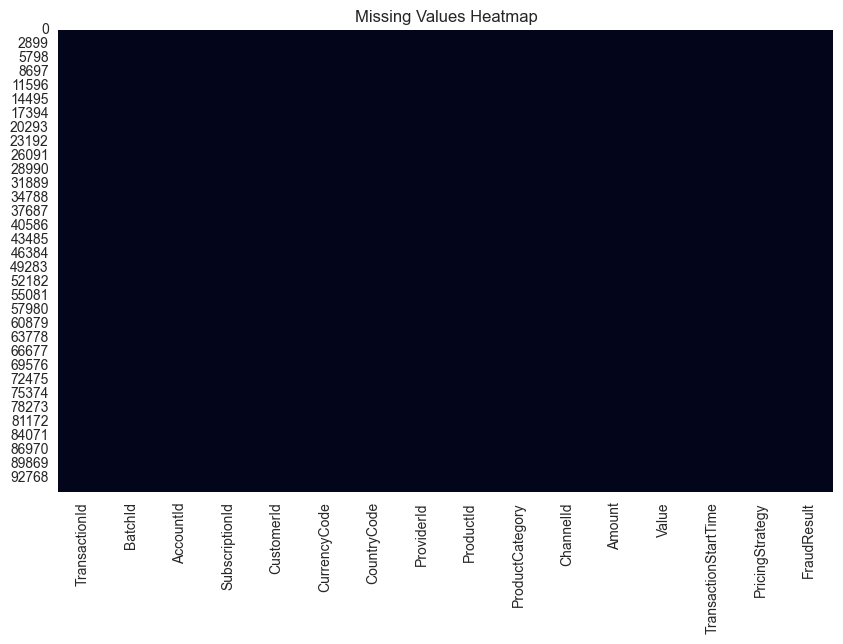


NUMERICAL COLUMNS: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']


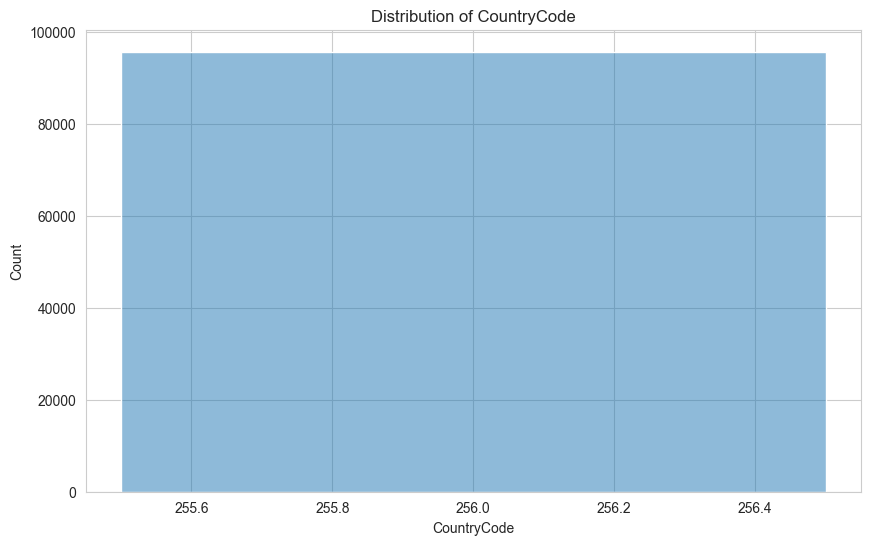

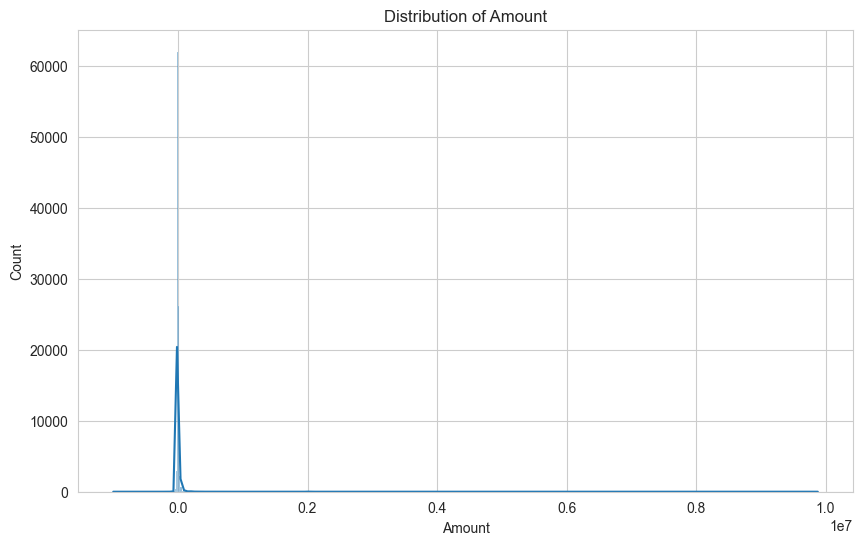

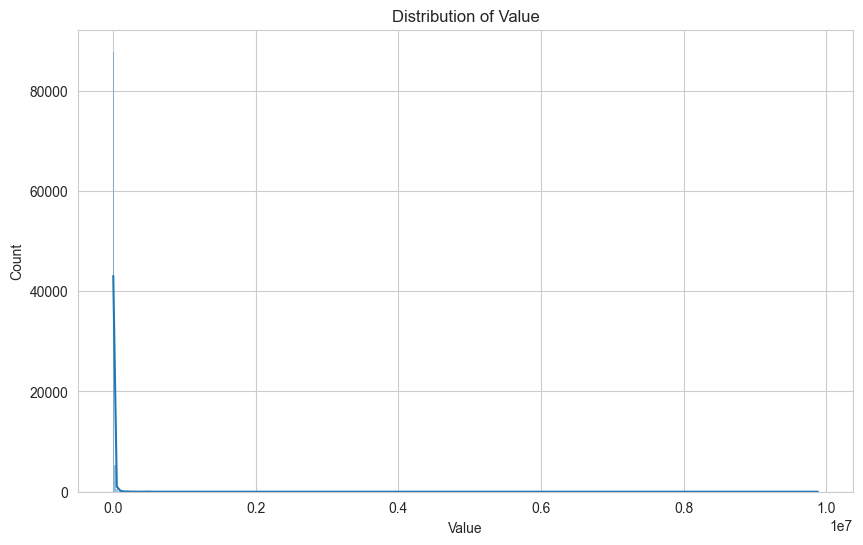

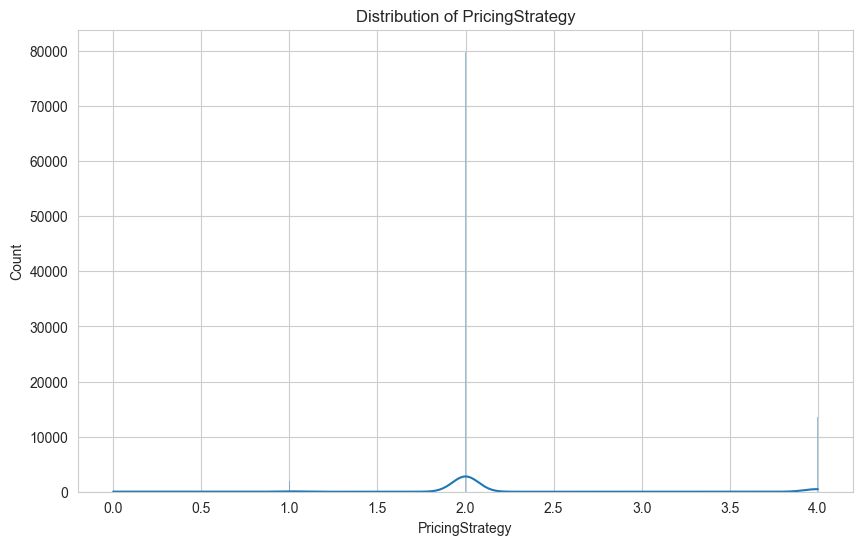

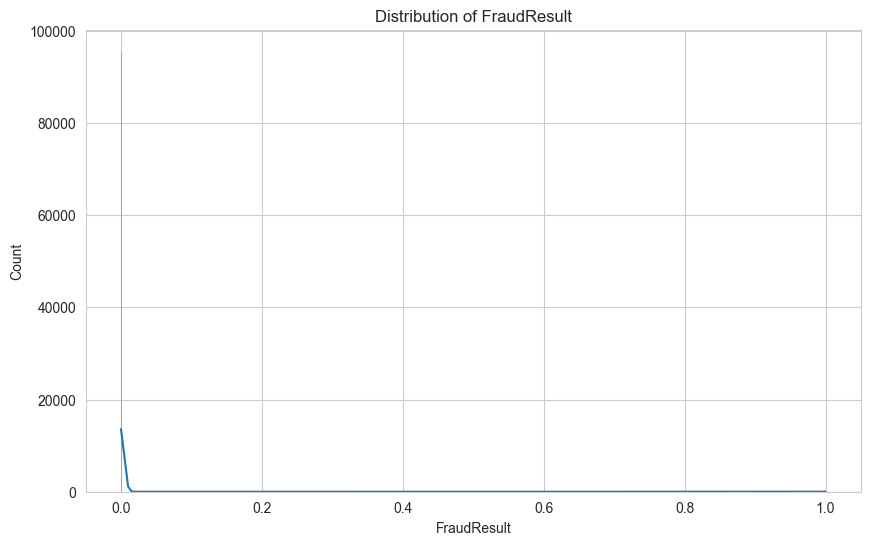

C:\Users\Test\AppData\Local\Temp\ipykernel_19976\3981631067.py:65: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns



CATEGORICAL COLUMNS: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']


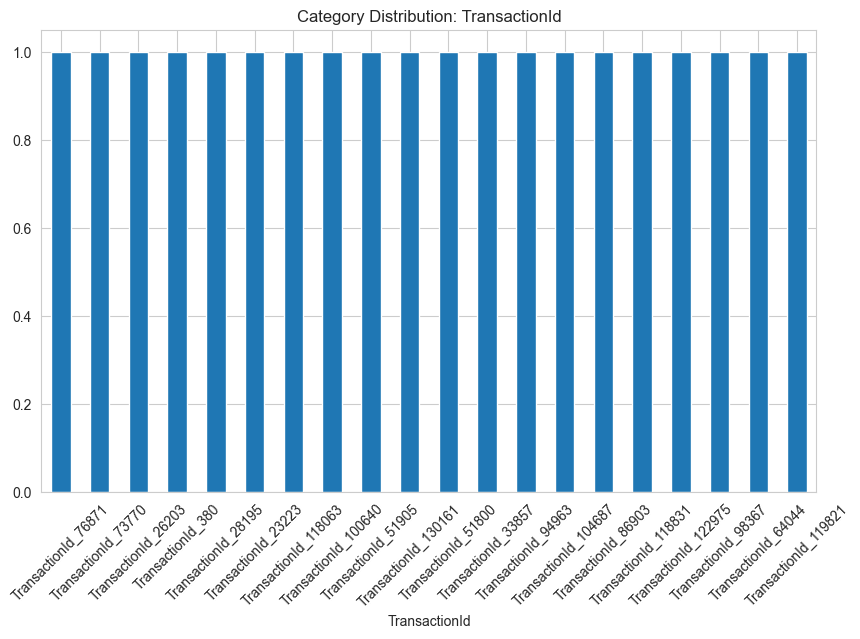

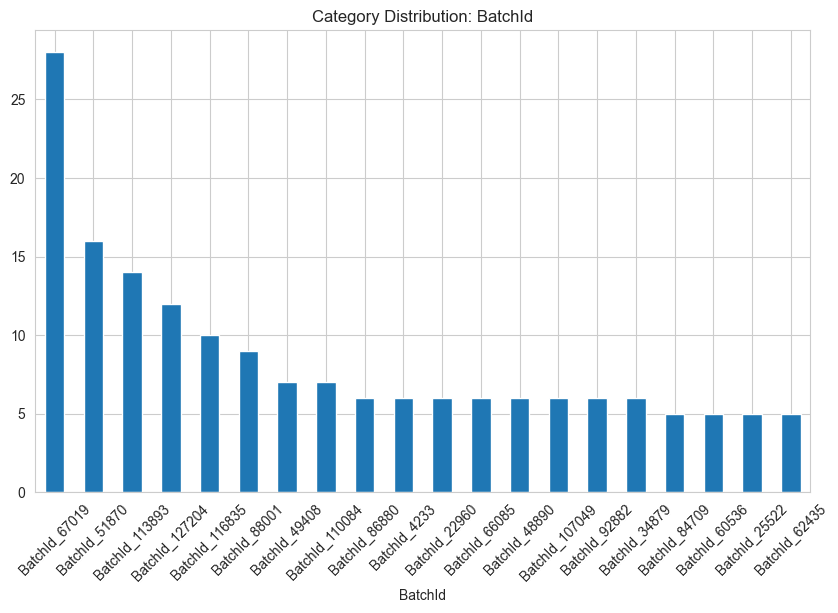

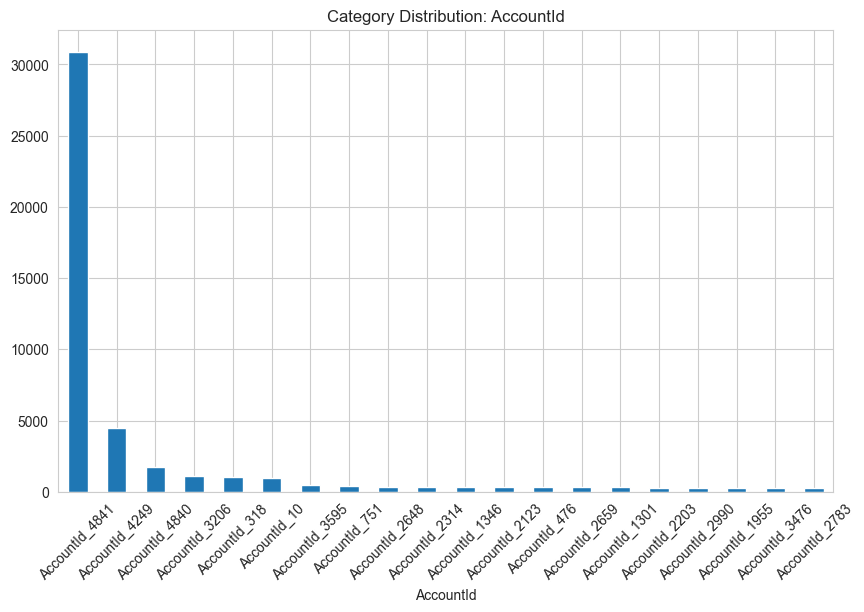

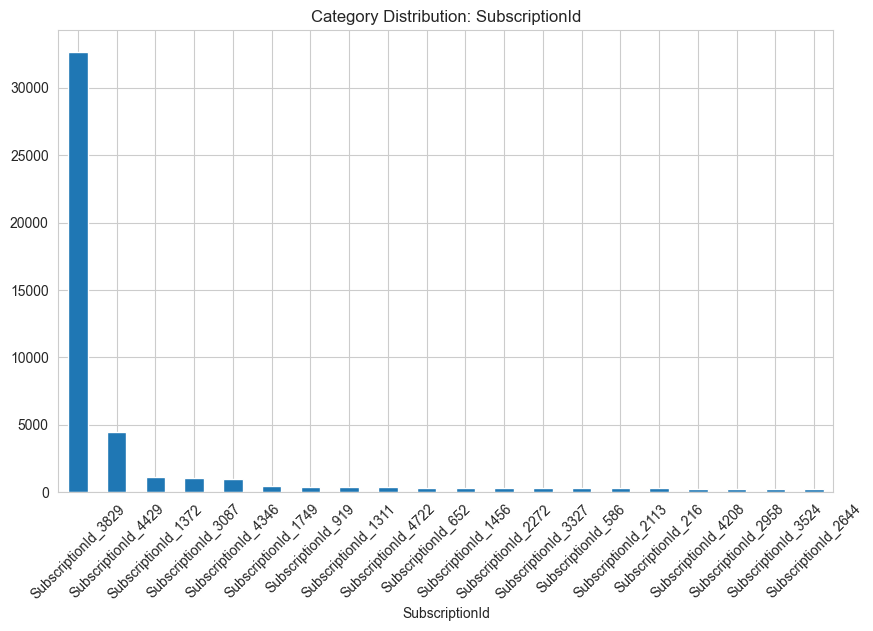

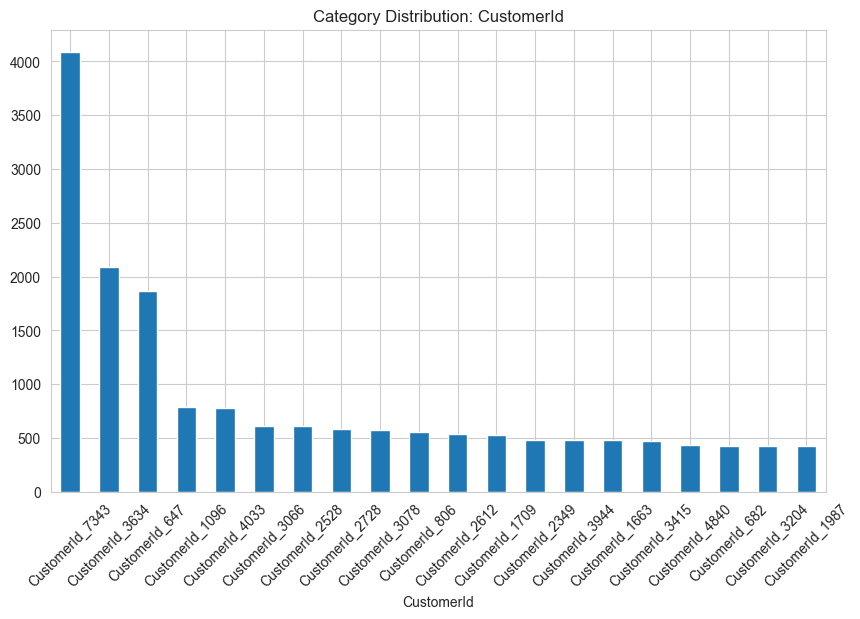

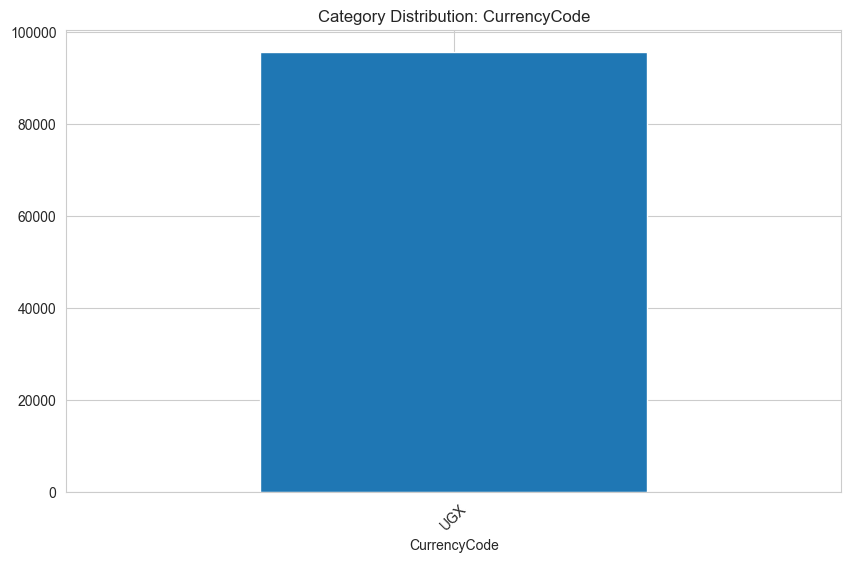

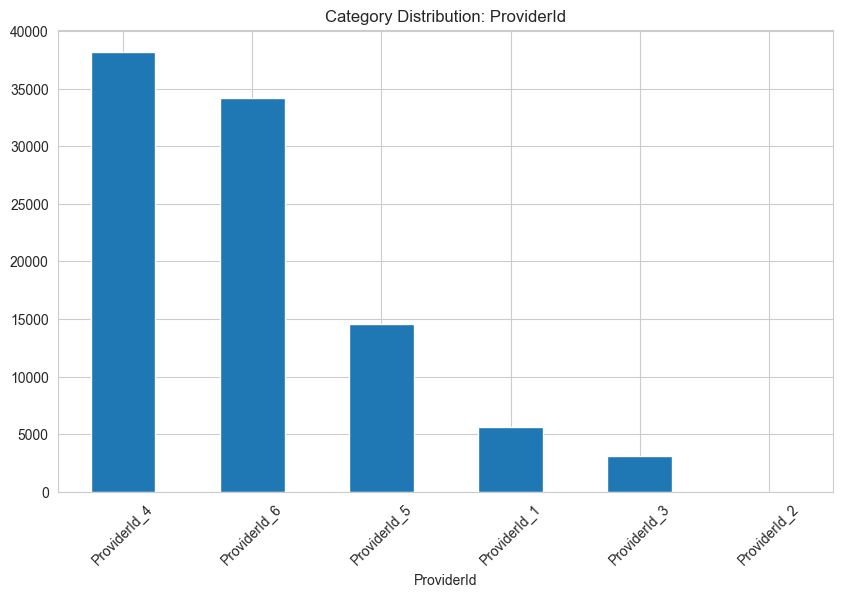

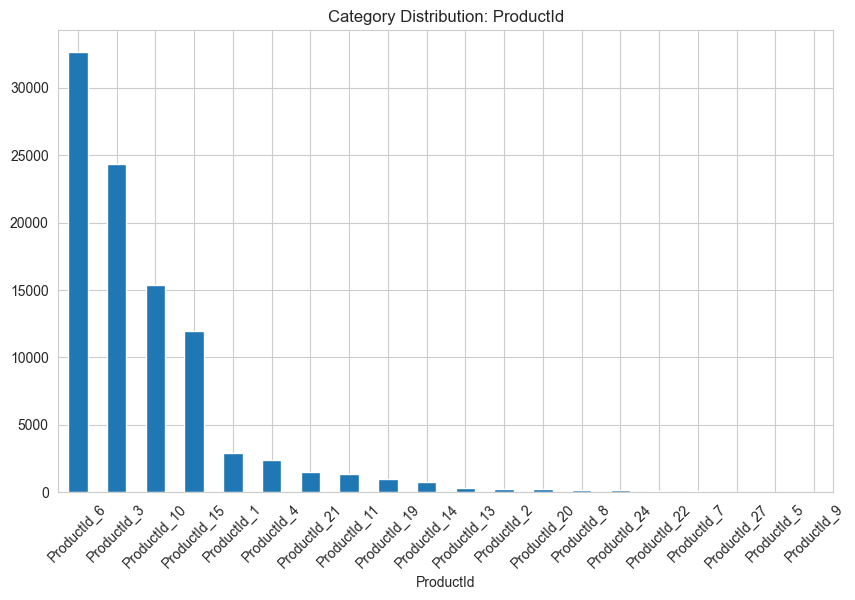

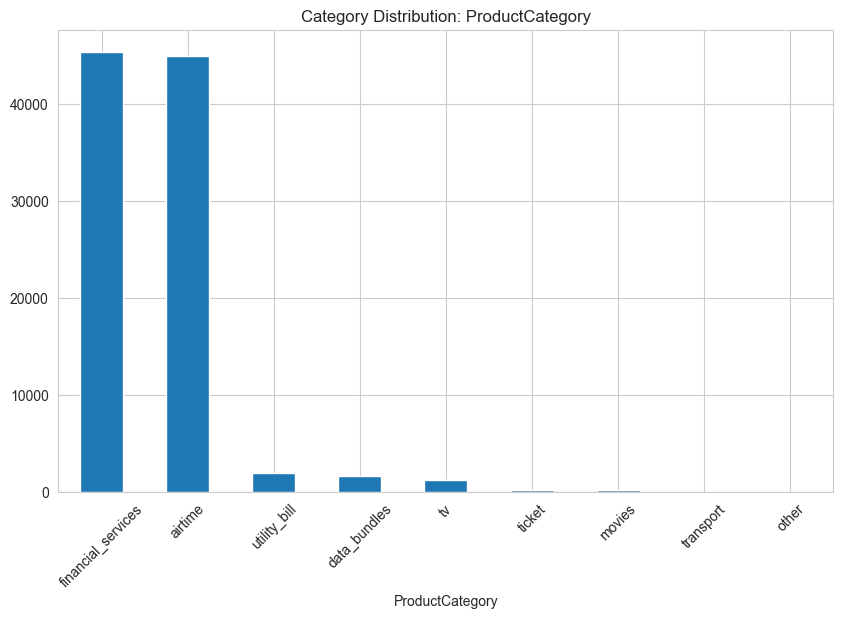

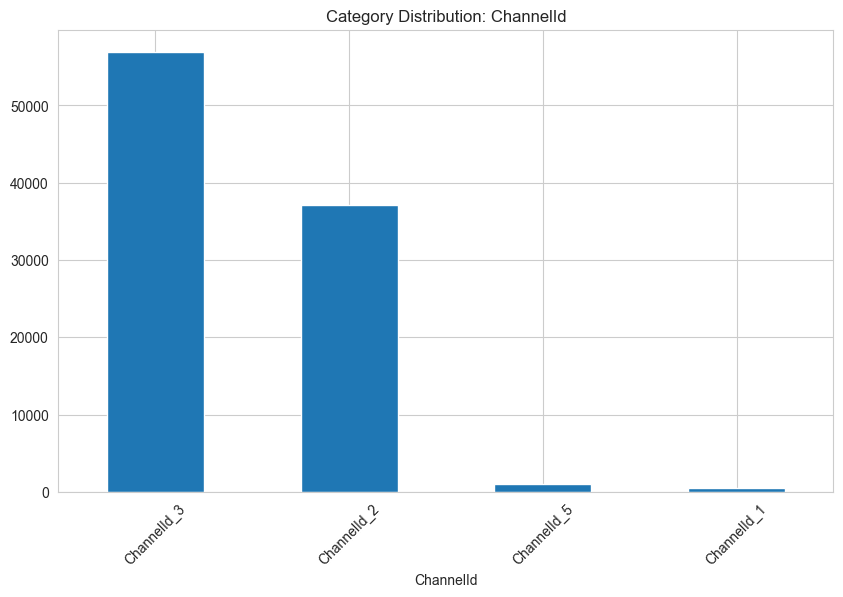

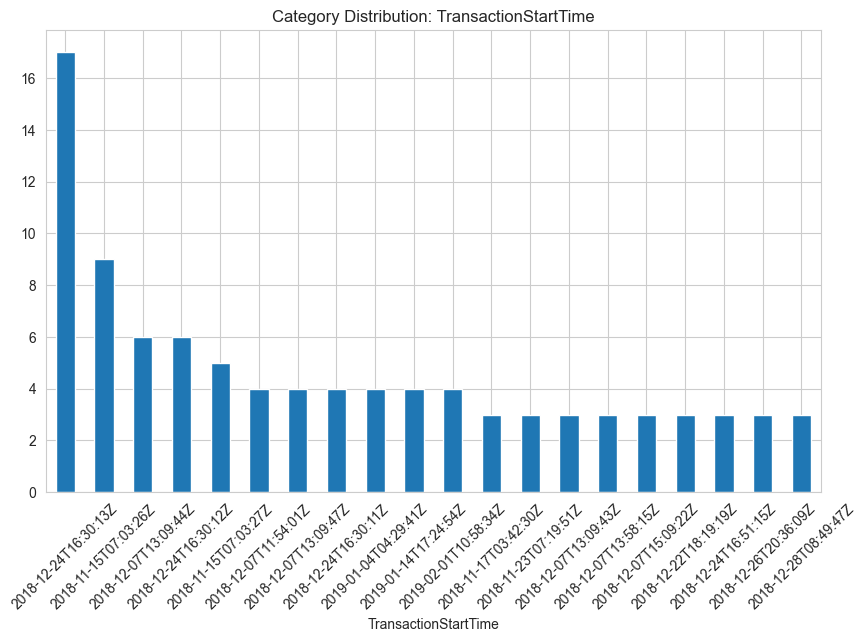

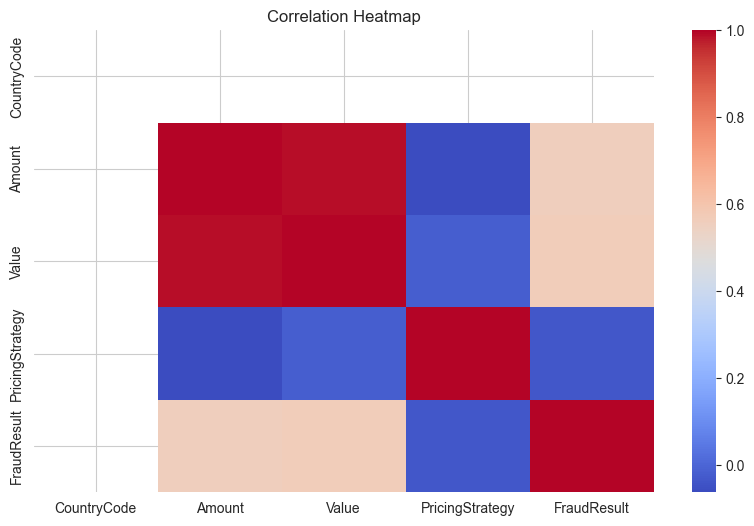

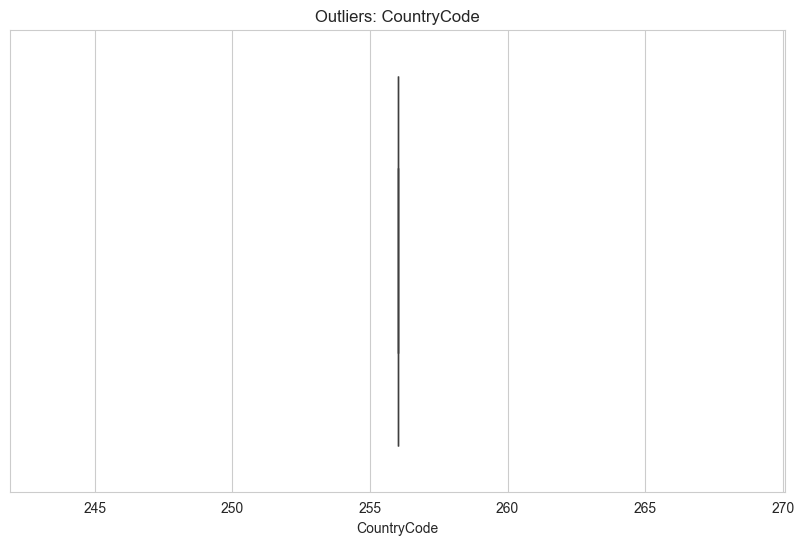

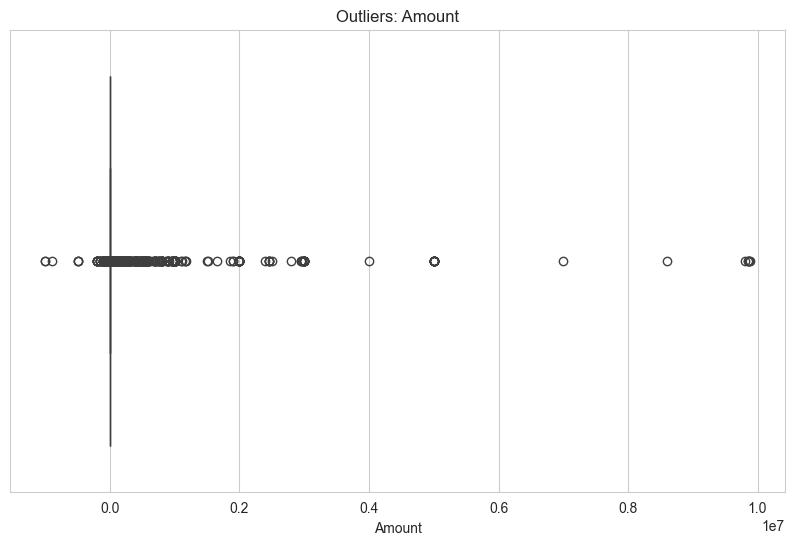

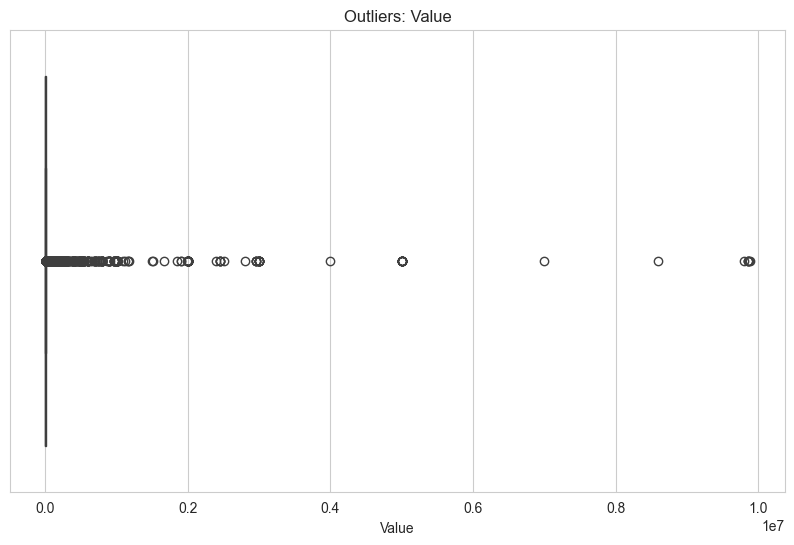

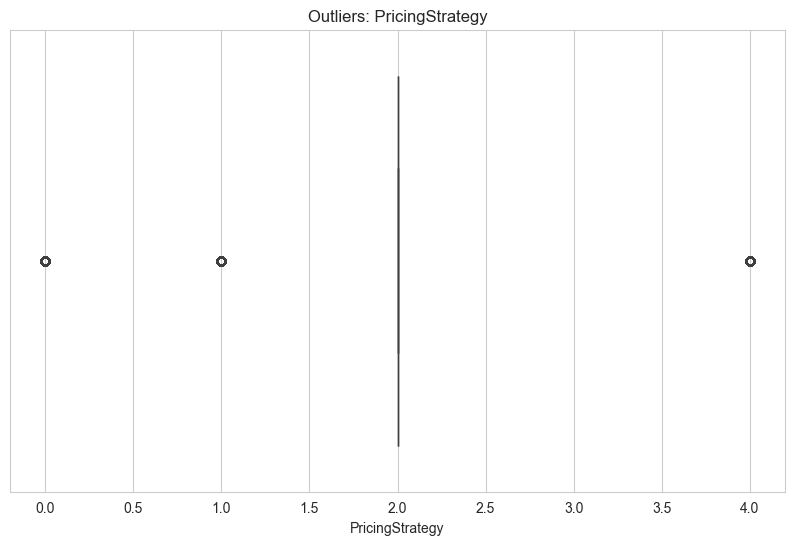

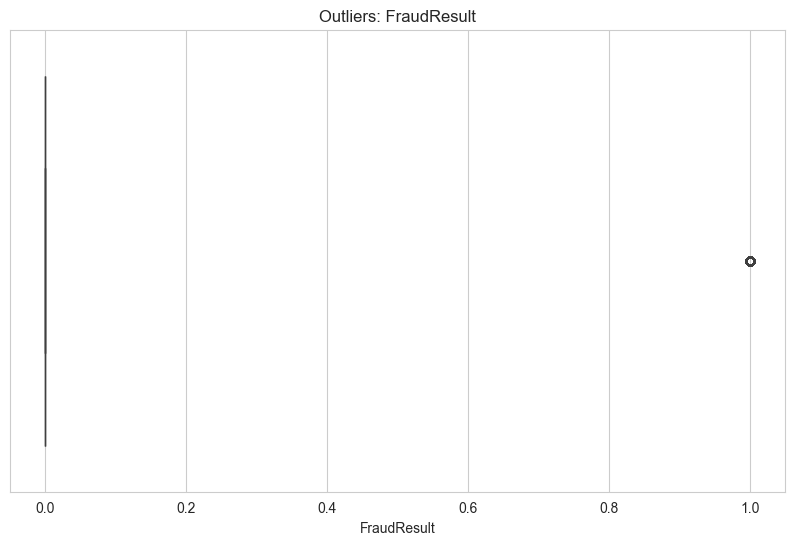


EDA INSIGHT CHECKLIST

1. Check skewed distributions in histograms
2. Check missing values for imputation strategy
3. Check correlation for multicollinearity
4. Check outliers for extreme values
5. Check category imbalance in categorical variables

DONE EDA


In [1]:
# ==============================
# CREDIT RISK EDA (ONE CELL)
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ------------------------------
# LOAD DATA
# ------------------------------
df = pd.read_csv("../data/raw/data.csv")  # <-- CHANGE THIS

print("SHAPE:", df.shape)
print("\nCOLUMNS:\n", df.columns)
print("\nINFO:")
print(df.info())

# ------------------------------
# SUMMARY STATISTICS
# ------------------------------
print("\nNUMERICAL SUMMARY:")
print(df.describe().T)

print("\nCATEGORICAL SUMMARY:")
print(df.describe(include="object").T)

# ------------------------------
# MISSING VALUES
# ------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMISSING VALUES:")
print(missing)

print("\nMISSING PERCENTAGE:")
print((df.isnull().mean()*100).sort_values(ascending=False))

plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# ------------------------------
# NUMERICAL DISTRIBUTIONS
# ------------------------------
num_cols = df.select_dtypes(include=np.number).columns

print("\nNUMERICAL COLUMNS:", list(num_cols))

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# ------------------------------
# CATEGORICAL DISTRIBUTIONS
# ------------------------------
cat_cols = df.select_dtypes(include="object").columns

print("\nCATEGORICAL COLUMNS:", list(cat_cols))

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"Category Distribution: {col}")
    plt.xticks(rotation=45)
    plt.show()

# ------------------------------
# CORRELATION
# ------------------------------
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------
# OUTLIERS (BOX PLOTS)
# ------------------------------
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers: {col}")
    plt.show()

# ------------------------------
# QUICK INSIGHT SUMMARY (PRINT)
# ------------------------------
print("\n==============================")
print("EDA INSIGHT CHECKLIST")
print("==============================")

print("\n1. Check skewed distributions in histograms")
print("2. Check missing values for imputation strategy")
print("3. Check correlation for multicollinearity")
print("4. Check outliers for extreme values")
print("5. Check category imbalance in categorical variables")

print("\nDONE EDA")